In [2]:
'SHARD MERGING'
#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)
#MOANA ONLY
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2


PID: 187365
CUDA_VISIBLE_DEVICES: None
hostname: cf331f7aa4bc
Failed to initialize NVML: Unknown Error



In [3]:
# Cell 0 — CONFIG
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    _linux_candidates = [Path("/knuckles_drive"), Path("/workspaces/MScPROJECT_LOCAL")]
    for _candidate in _linux_candidates:
        if _candidate.exists():
            project_root = _candidate
            break
    else:
        raise FileNotFoundError(f"None of the known project_root paths exist: {_linux_candidates}")
load_dotenv(project_root / ".env")
case_name = "07_Tropea_cafe"

experiment = "cat_04"

asset_name = f"{case_name}_{experiment}"
from A_Config import set_case
set_case(case_name, experiment)


#These neeed work
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir     / "010_source"
query_dir    = case_dir     / "012_Gemini_outputs"
yolo_masks_dir = case_dir   / "015_YOLO" / experiment
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir   / "020_frames_for_recon" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
predictions_path =  case_dir   /  VGGT_O_output_dir /"predictions.npz" 
CUT3R_output_dir    = case_dir   /"035_CUT3R_output" / experiment

#temp - need to sort out a unified place? no visualisation is justfor me
reg_dir        = case_dir     / "030_Registrations"
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags.csv"
csv_path_pose = reg_dir     /"camera_poses.csv"


FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")
#FLAGS
VID_TO_TEXT     = True
TRACKING        = True
FRAME_SELECTION = True
RECON_CAM_POSES = True
RECON_3D_DO      = False
CUT3R_RECON     = True
MEGA_SAM_RECON  = False
VGGT_RECON      = False
VGGT_O_RECON    = True
MULTI_PART_RECON = True
GOOGLE_MAP      = False
PROJECTION_MAP  = True
MAKE_MOVIE      = False

Case    : 07_Tropea_cafe
Video   : VID_20260530_113822990.mp4


In [6]:
#VGGT OMEGA (sharded)
# Cell — VGGT-Omega reconstruction across multiple GPUs
if VGGT_O_RECON == True and RECON_3D_DO == True and MULTI_PART_RECON == False:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards

    recon_out = case_dir / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards(
        image_dir              = str(frames_for_recon),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 512,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")

    

Cell disabled


In [8]:
#VGGT OMEGA (sharded) BATCH
# Cell — VGGT-Omega reconstruction across multiple GPUs - run a long sequence thorugh the batch processor.
#it sends in batches of 100 with an overlap of 1 frame for later alignment
if VGGT_O_RECON == True and RECON_3D_DO == True and MULTI_PART_RECON == True:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards_batched

    recon_out = case_dir / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards_batched(
        image_dir              = str(frames_for_recon),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 512,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")

    

Cell disabled


In [9]:
#temp for already solved 
RECON_CAM_POSES = True

3.9820025985184495


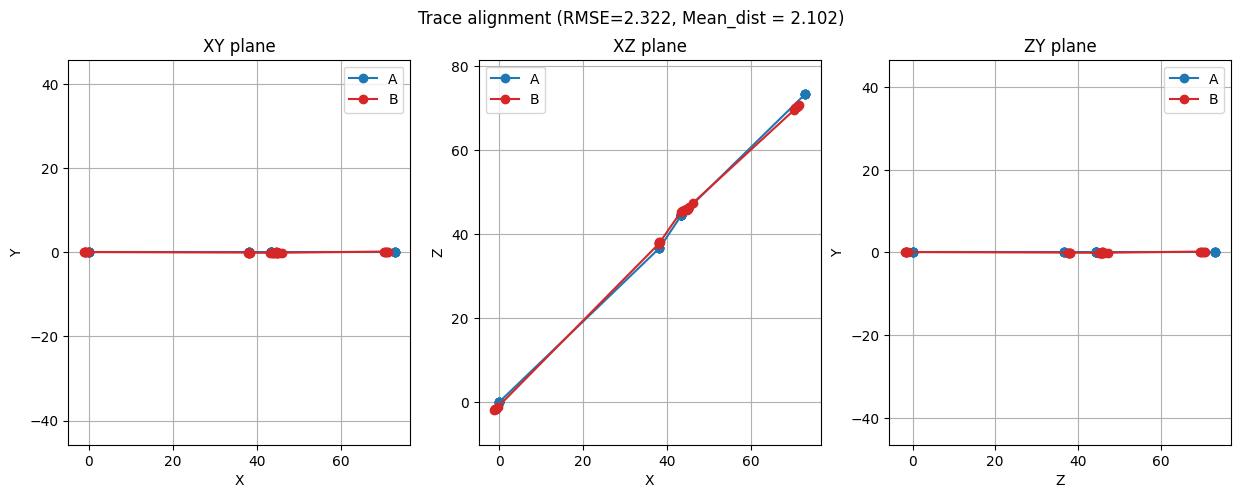

In [5]:
#convert CAMERA POSES from model-world-space into real-world-space (RS formatted at the moment)
if RECON_CAM_POSES == True and VGGT_O_RECON ==True:
    
    #get lat lon positions
    #get transforms to convert other things too
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
    cam_poses_realworld_dict, cam_latlons, R, s, t, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, csv_path_pose)
else:
    print("Cell disabled")
print(s)

In [6]:
from E_post_recon_processing import Reconstruction
if VGGT_O_RECON == True:
    if MULTI_PART_RECON == True:
        from B_VGGT_O_shards import discover_vggt_omega_shards
        from F_transforms_alignments import umeyama_align, recon_to_recon_transform, combine_transforms
        print("A")
        shards = discover_vggt_omega_shards(VGGT_O_output_dir)
        print("B")
        #makes list of recons.
        recons = [
            Reconstruction.load(frames_for_recon, npz_path, FRAME_NAME_FMT, frame_range=(start, end))
            for start, end, npz_path in shards
        ]
        print(f"loaded {len(recons)} recon shards: {[(s, e) for s, e, _ in shards]}")
        multi = True

A
B
loaded 3 recon shards: [(0, 100), (99, 199), (198, 245)]


A
B
loaded 3 recon shards: [(0, 100), (99, 199), (198, 245)]
merging
Subject VGGT-O → real-world: 5 pairs, RMSE = 0.0219 m


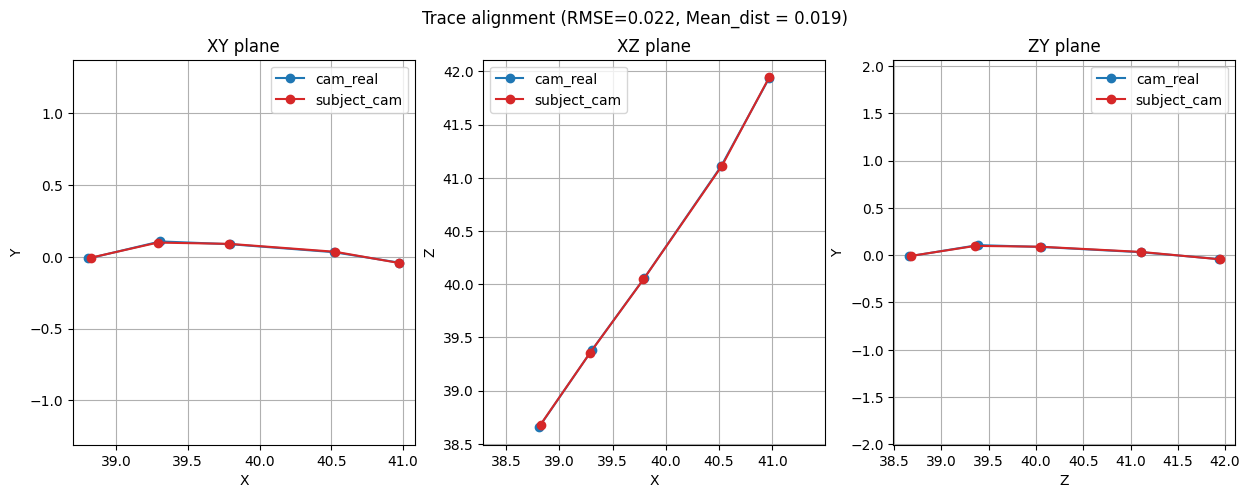

In [7]:
#MULTI MERGE and PLY maker
#processes spatial information about the subject - for report and generates the data needed to map the subject
from E_post_recon_processing import Reconstruction
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
if VGGT_O_RECON == True:
    if MULTI_PART_RECON == True:
        from B_VGGT_O_shards import discover_vggt_omega_shards
        from F_transforms_alignments import umeyama_align, recon_to_recon_transform, combine_transforms
            
        #transforms to get separate recons to align with each other - save until all transforms are made
        print("merging")
        #get tranform needed to turn first recon from modelspace into real world
        R_mw , s_mw, t_mw  = recon_to_recon_transform(recons[0],cam_poses_realworld_dict)
        merge_xforms = [(R_mw , s_mw, t_mw)]
        
        #use overlapping frames to align the recon shards
        #start with the model to world
        R = R_mw
        s = s_mw
        t = t_mw
        #for poitn clouds: we don't want the real world
        Rpc = np.eye(3)
        spc = 1
        tpc = 0
        point_cloud_xforms = [(Rpc , spc, tpc)]
     
        for i in range(len(recons)):
            #for point cloud rendering
            #rotate, scale and transform the points into real-world space and then transform to the very first camera's position
            centre = recons[i].VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R, t=t, s=s, multi=multi, centre_to_cam00=t_mw)
            #load up same frame's points from the 2 recons that overlap
            #now to prepare the transform for the next shard
            if i+1 <len(recons): 
                #EXTRINSICS of the one that's already been done
                #rotation+translation of final frame into model space when i =0, this is cam 0
                extr = recons[i].preds["extrinsic"][-1].cpu().numpy()      #(3,4) model->cam matrix 
                R_cm = extr[:3, :3].T                               #cam-to-model rotation 
                t_cm= -R_cm @ extr[:3, 3]                   #cam to model translation

                #extrinsics of the one to be done are all 00000, so we don't need it.
                #but we do need scale: 
                #  fx/fy ratios they won't match - since VGGT normalises
                intr_to   = recons[i].preds["intrinsic"][-1].cpu().numpy()   
                intr_from = recons[i+1].preds["intrinsic"][0].cpu().numpy()  
                fx_ratio = intr_from[0, 0] / intr_to[0, 0]
                fy_ratio = intr_from[1, 1] / intr_to[1, 1]
                if abs(fx_ratio - fy_ratio) / min(fx_ratio, fy_ratio) > 0.05:
                    print(f"WARNING junction {i}->{i+1}: fx/fy scale ratios disagree by >5% "
                          f"(fx={fx_ratio:.4f}, fy={fy_ratio:.4f}) - inspect this shared frame")
                s_cm = np.sqrt(fx_ratio * fy_ratio)   #geometric mean = least-squares combiner in log-space for a multiplicative factor
             
                #then merge into 1 set of transforms
                R,s,t = combine_transforms(R_cm, s_cm, t_cm, R, s, t) 
                #point cloud transformers
                Rpc, spc, tpc = combine_transforms(R_cm, s_cm, t_cm, Rpc, spc, tpc) 
                merge_xforms.append((R,s,t))
                point_cloud_xforms.append((Rpc, spc, tpc)) 

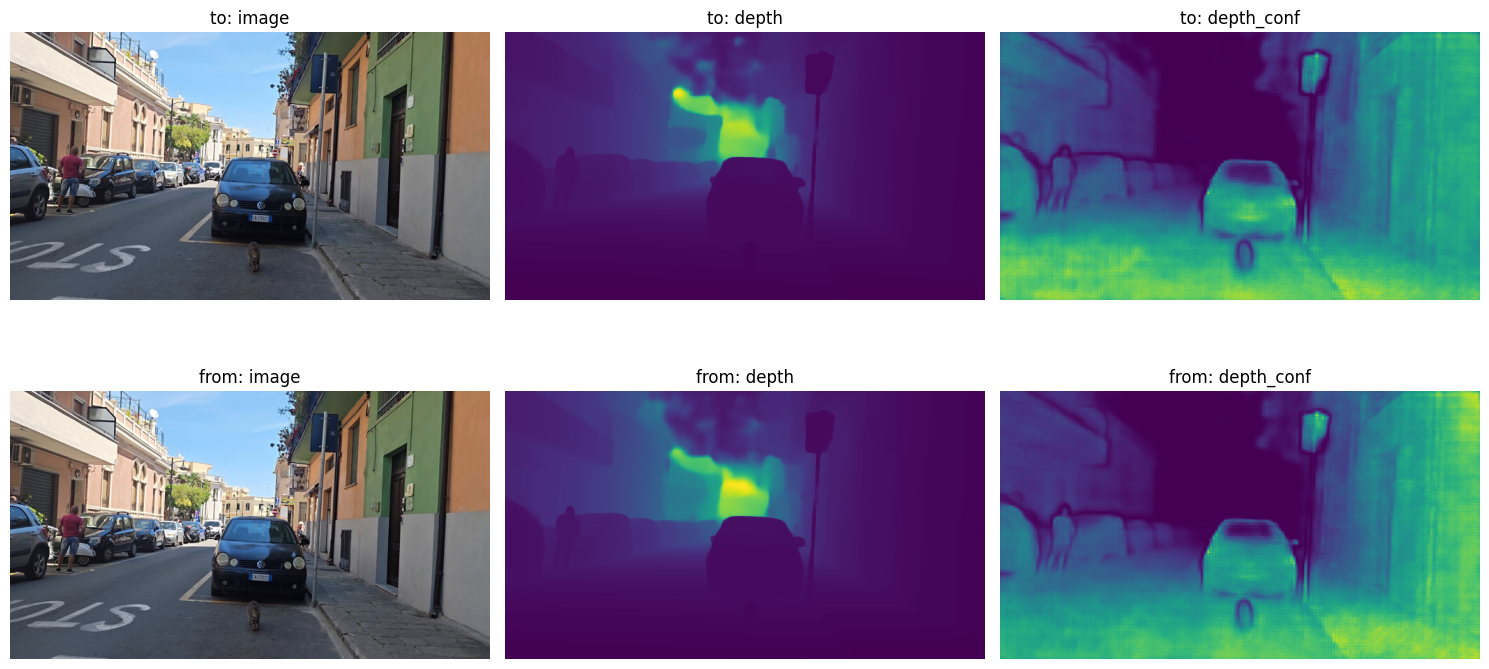

max abs image diff: 0.0


In [19]:
#QUICK LOOK AT DEPTH MAPS
import matplotlib.pyplot as plt

row_to, row_from = -1, 0   # recons[i]'s last frame vs recons[i+1]'s first frame

img_to    = recons[1].preds["images"][row_to].permute(1, 2, 0).cpu().numpy()
img_from  = recons[2].preds["images"][row_from].permute(1, 2, 0).cpu().numpy()
depth_to    = recons[1].preds["depth"][row_to].cpu().numpy()
depth_from  = recons[2].preds["depth"][row_from].cpu().numpy()
conf_to     = recons[1].preds["depth_conf"][row_to].cpu().numpy()
conf_from   = recons[2].preds["depth_conf"][row_from].cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, im, title in zip(
    axes.ravel(),
    [img_to, depth_to, conf_to, img_from, depth_from, conf_from],
    ["to: image", "to: depth", "to: depth_conf", "from: image", "from: depth", "from: depth_conf"],
):
    ax.imshow(im, cmap=None if im.ndim == 3 else "viridis")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("max abs image diff:", (img_to - img_from).abs().max() if hasattr(img_to, "abs") else abs(img_to - img_from).max())


depth_to   range: [0.2177, 7.8613]
depth_from range: [0.2364, 7.6744]
combined range (max-min across both): 7.6436
mean abs diff as % of combined range: 1.84%
max abs diff as % of combined range: 45.08%



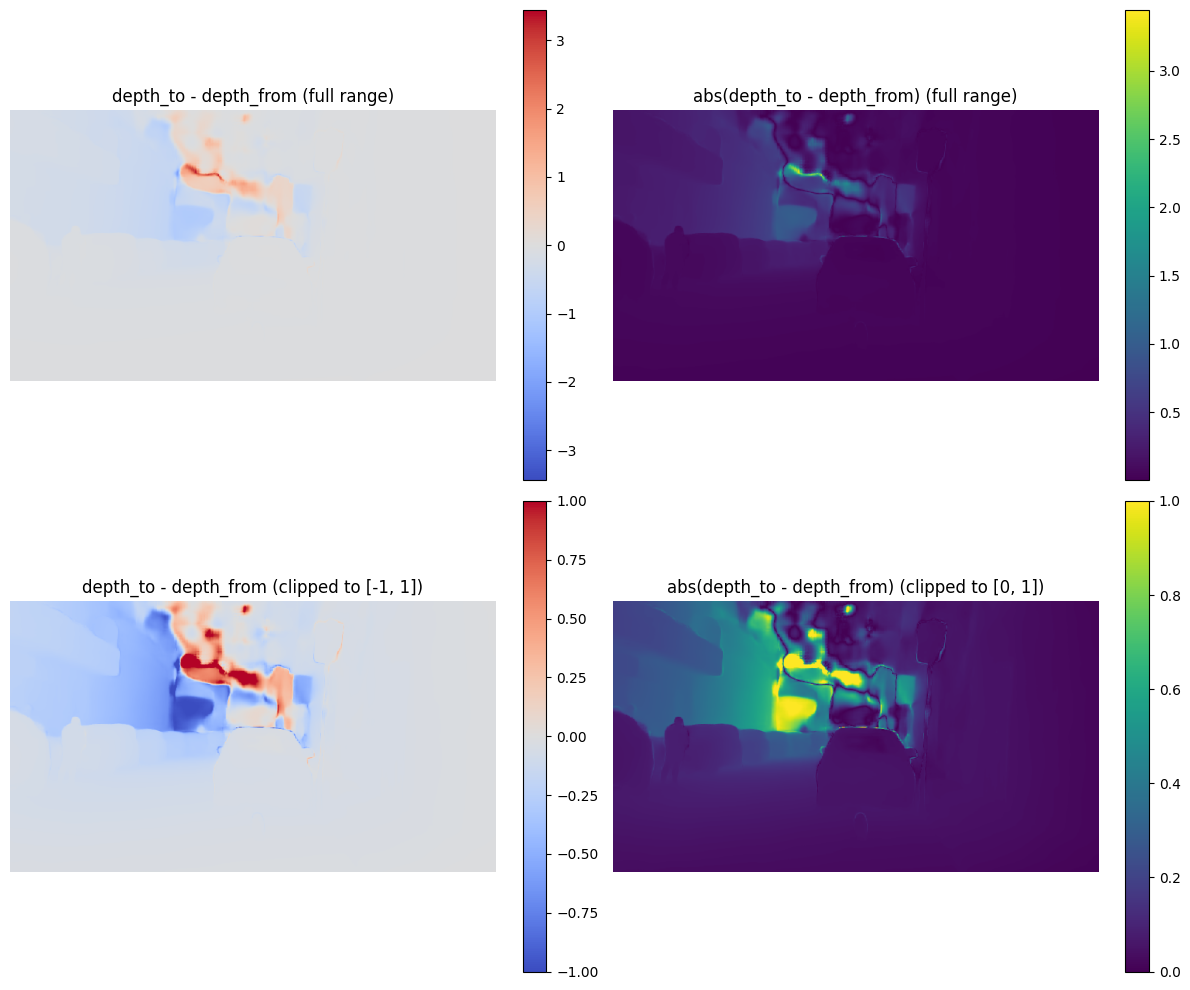

mean abs depth diff: 0.14093718
max abs depth diff: 3.445692
fraction of pixels with abs diff > 1: 0.65%


In [20]:
#DEPTH DIFF: to vs from (raw preds["depth"], no unproject/transform)
row_to, row_from = -1, 0   # recons[i]'s last frame vs recons[i+1]'s first frame

depth_to    = recons[1].preds["depth"][row_to].cpu().numpy()
depth_from  = recons[2].preds["depth"][row_from].cpu().numpy()

depth_diff = depth_to - depth_from
depth_range = max(depth_to.max(), depth_from.max()) - min(depth_to.min(), depth_from.min())

print(f"depth_to   range: [{depth_to.min():.4f}, {depth_to.max():.4f}]")
print(f"depth_from range: [{depth_from.min():.4f}, {depth_from.max():.4f}]")
print(f"combined range (max-min across both): {depth_range:.4f}")
print(f"mean abs diff as % of combined range: {100 * np.abs(depth_diff).mean() / depth_range:.2f}%")
print(f"max abs diff as % of combined range: {100 * np.abs(depth_diff).max() / depth_range:.2f}%")
print()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(depth_diff, cmap="coolwarm", vmin=-np.abs(depth_diff).max(), vmax=np.abs(depth_diff).max())
axes[0, 0].set_title("depth_to - depth_from (full range)")
axes[0, 0].axis("off")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(np.abs(depth_diff), cmap="viridis")
axes[0, 1].set_title("abs(depth_to - depth_from) (full range)")
axes[0, 1].axis("off")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# near-field view: clip to +/-1 so distant/far-scale differences don't wash out
# what's happening on objects that are actually close (<1 unit away)
depth_diff_clipped = np.clip(depth_diff, -1, 1)
im2 = axes[1, 0].imshow(depth_diff_clipped, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 0].set_title("depth_to - depth_from (clipped to [-1, 1])")
axes[1, 0].axis("off")
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046)

abs_diff_clipped = np.clip(np.abs(depth_diff), 0, 1)
im3 = axes[1, 1].imshow(abs_diff_clipped, cmap="viridis", vmin=0, vmax=1)
axes[1, 1].set_title("abs(depth_to - depth_from) (clipped to [0, 1])")
axes[1, 1].axis("off")
fig.colorbar(im3, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()

print("mean abs depth diff:", np.abs(depth_diff).mean())
print("max abs depth diff:", np.abs(depth_diff).max())
print(f"fraction of pixels with abs diff > 1: {(np.abs(depth_diff) > 1).mean() * 100:.2f}%")


depth_to   range: [0.4018, 8.1503]
depth_from range: [0.2364, 7.6741]
combined range (max-min across both): 7.9140
mean abs diff as % of combined range: 2.10%
max abs diff as % of combined range: 46.28%



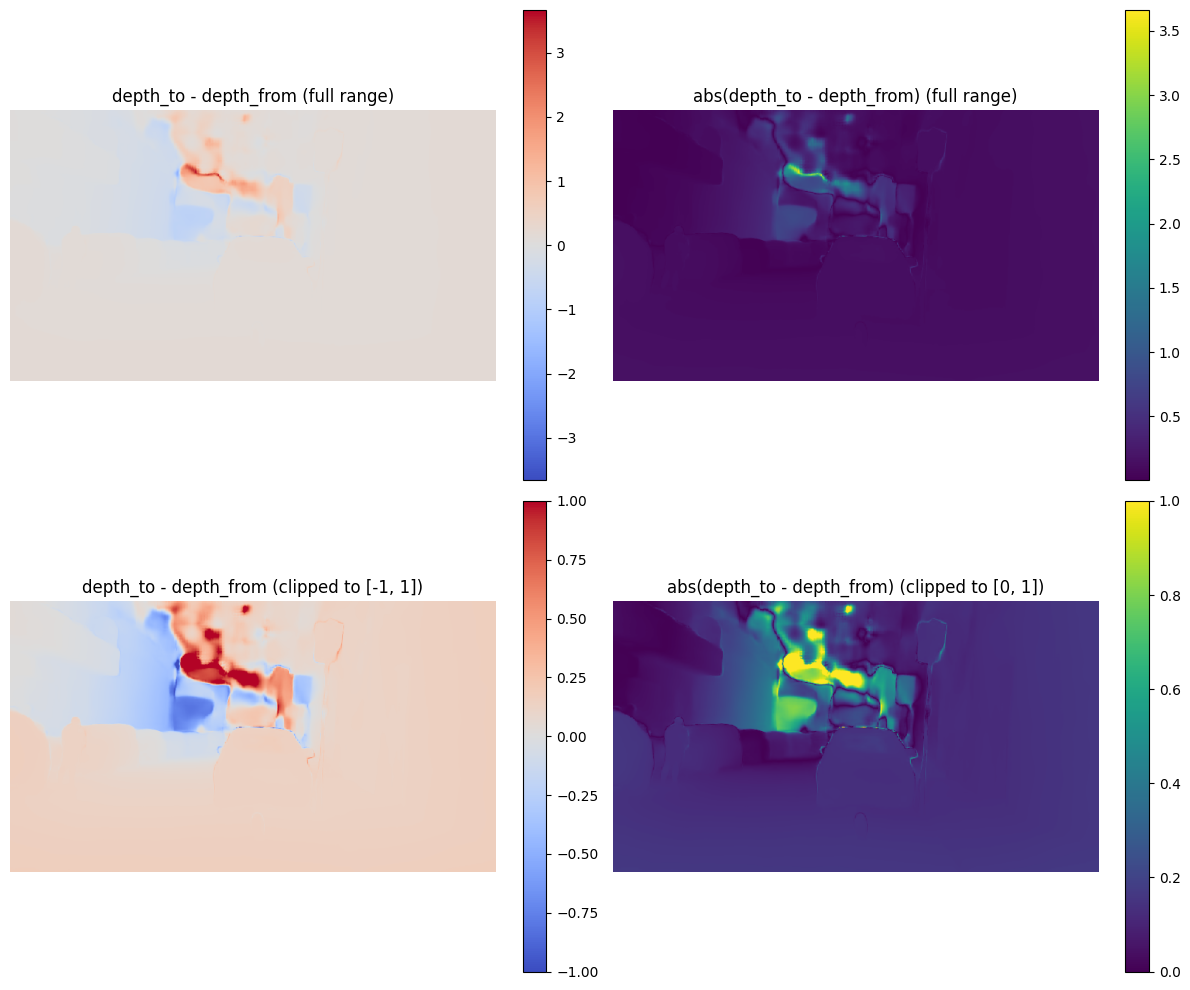

mean abs depth diff: 0.16628075
max abs depth diff: 3.6627605
fraction of pixels with abs diff > 1: 0.71%


In [16]:
#DEPTH DIFF: to vs from UNprojected in model space
#can't just re-read the plys here since the confidence filter drops the overlap frame's
#points differently in each shard's export -- recompute both from their own preds instead,
#via the same unproject() the merge cell uses. z is unproject()'s 3rd output column, in
#each shard's own model/cam0 frame (not raw network depth -- that gets rotated by unproject).
from F_transforms_alignments import unproject

row_to, row_from = -1, 0   # recons[i]'s last frame vs recons[i+1]'s first frame

points_to   = unproject(recons[1].preds["depth"][row_to],   recons[1].preds["intrinsic"][row_to],   recons[1].preds["extrinsic"][row_to])
points_from = unproject(recons[2].preds["depth"][row_from], recons[2].preds["intrinsic"][row_from], recons[2].preds["extrinsic"][row_from])
depth_to   = points_to[..., 2].cpu().numpy()
depth_from = points_from[..., 2].cpu().numpy()

depth_diff = depth_to - depth_from
depth_range = max(depth_to.max(), depth_from.max()) - min(depth_to.min(), depth_from.min())

print(f"depth_to   range: [{depth_to.min():.4f}, {depth_to.max():.4f}]")
print(f"depth_from range: [{depth_from.min():.4f}, {depth_from.max():.4f}]")
print(f"combined range (max-min across both): {depth_range:.4f}")
print(f"mean abs diff as % of combined range: {100 * np.abs(depth_diff).mean() / depth_range:.2f}%")
print(f"max abs diff as % of combined range: {100 * np.abs(depth_diff).max() / depth_range:.2f}%")
print()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(depth_diff, cmap="coolwarm", vmin=-np.abs(depth_diff).max(), vmax=np.abs(depth_diff).max())
axes[0, 0].set_title("depth_to - depth_from (full range)")
axes[0, 0].axis("off")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(np.abs(depth_diff), cmap="viridis")
axes[0, 1].set_title("abs(depth_to - depth_from) (full range)")
axes[0, 1].axis("off")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# near-field view: clip to +/-1 so distant/far-scale differences don't wash out
# what's happening on objects that are actually close (<1 unit away)
depth_diff_clipped = np.clip(depth_diff, -1, 1)
im2 = axes[1, 0].imshow(depth_diff_clipped, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 0].set_title("depth_to - depth_from (clipped to [-1, 1])")
axes[1, 0].axis("off")
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046)

abs_diff_clipped = np.clip(np.abs(depth_diff), 0, 1)
im3 = axes[1, 1].imshow(abs_diff_clipped, cmap="viridis", vmin=0, vmax=1)
axes[1, 1].set_title("abs(depth_to - depth_from) (clipped to [0, 1])")
axes[1, 1].axis("off")
fig.colorbar(im3, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()

print("mean abs depth diff:", np.abs(depth_diff).mean())
print("max abs depth diff:", np.abs(depth_diff).max())
print(f"fraction of pixels with abs diff > 1: {(np.abs(depth_diff) > 1).mean() * 100:.2f}%")


depth_to   range: [46.3147, 153.9010]
depth_from range: [46.1093, 133.0205]
combined range (max-min across both): 107.7918
mean abs diff as % of combined range: 1.41%
max abs diff as % of combined range: 45.11%



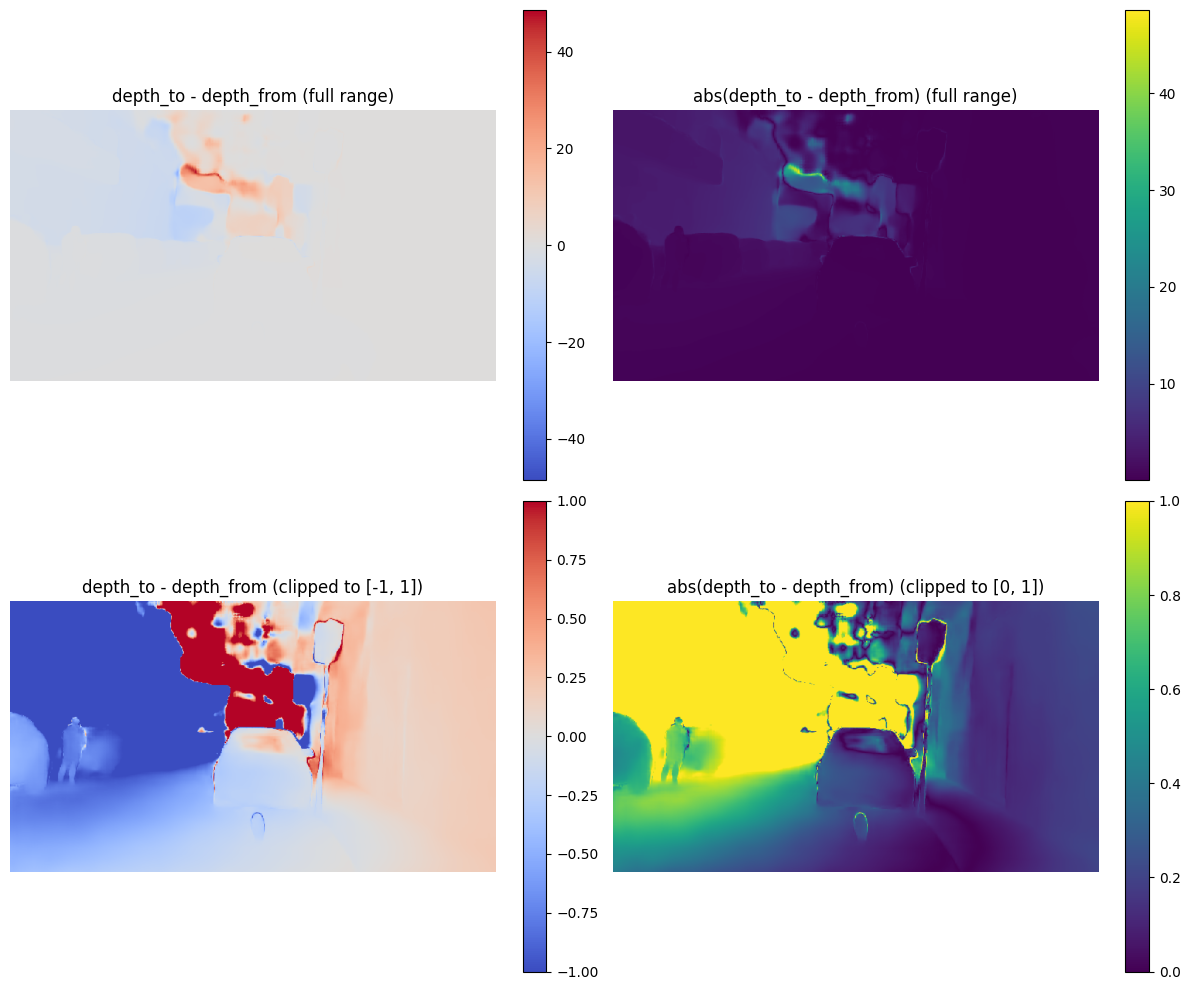

mean abs depth diff: 1.5248809168360504
max abs depth diff: 48.622030252161224
fraction of pixels with abs diff > 1: 28.03%


In [18]:
#Now repeat the graphs after merging into real-world/model space
#DEPTH DIFF: to vs from (post R_mw/s_mw/t_mw)
#R_mw, s_mw, t_mw operate on unprojected model-space points -- see transform_RST /
#Q_subject_analysis.subject_to_metric_and_gps_space, same math. z is the 3rd column
#after that transform, in the shared merged frame this time (not each shard's own frame).
from F_transforms_alignments import unproject, transform_RST

row_to, row_from = -1, 0   # recons[i]'s last frame vs recons[i+1]'s first frame

points_to   = unproject(recons[1].preds["depth"][row_to],   recons[1].preds["intrinsic"][row_to],   recons[1].preds["extrinsic"][row_to])
points_from = unproject(recons[2].preds["depth"][row_from], recons[2].preds["intrinsic"][row_from], recons[2].preds["extrinsic"][row_from])

h, w, _ = points_to.shape
R_to,   s_to,   t_to   = merge_xforms[1]
R_from, s_from, t_from = merge_xforms[2]
points_to_world   = transform_RST(points_to.reshape(-1, 3).cpu().numpy(),   R_to,   s_to,   t_to).reshape(h, w, 3)
points_from_world = transform_RST(points_from.reshape(-1, 3).cpu().numpy(), R_from, s_from, t_from).reshape(h, w, 3)

depth_to   = points_to_world[..., 2]
depth_from = points_from_world[..., 2]

depth_diff = depth_to - depth_from
depth_range = max(depth_to.max(), depth_from.max()) - min(depth_to.min(), depth_from.min())

print(f"depth_to   range: [{depth_to.min():.4f}, {depth_to.max():.4f}]")
print(f"depth_from range: [{depth_from.min():.4f}, {depth_from.max():.4f}]")
print(f"combined range (max-min across both): {depth_range:.4f}")
print(f"mean abs diff as % of combined range: {100 * np.abs(depth_diff).mean() / depth_range:.2f}%")
print(f"max abs diff as % of combined range: {100 * np.abs(depth_diff).max() / depth_range:.2f}%")
print()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(depth_diff, cmap="coolwarm", vmin=-np.abs(depth_diff).max(), vmax=np.abs(depth_diff).max())
axes[0, 0].set_title("depth_to - depth_from (full range)")
axes[0, 0].axis("off")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(np.abs(depth_diff), cmap="viridis")
axes[0, 1].set_title("abs(depth_to - depth_from) (full range)")
axes[0, 1].axis("off")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# near-field view: clip to +/-1 so distant/far-scale differences don't wash out
# what's happening on objects that are actually close (<1 unit away)
depth_diff_clipped = np.clip(depth_diff, -1, 1)
im2 = axes[1, 0].imshow(depth_diff_clipped, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 0].set_title("depth_to - depth_from (clipped to [-1, 1])")
axes[1, 0].axis("off")
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046)

abs_diff_clipped = np.clip(np.abs(depth_diff), 0, 1)
im3 = axes[1, 1].imshow(abs_diff_clipped, cmap="viridis", vmin=0, vmax=1)
axes[1, 1].set_title("abs(depth_to - depth_from) (clipped to [0, 1])")
axes[1, 1].axis("off")
fig.colorbar(im3, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()

print("mean abs depth diff:", np.abs(depth_diff).mean())
print("max abs depth diff:", np.abs(depth_diff).max())
print(f"fraction of pixels with abs diff > 1: {(np.abs(depth_diff) > 1).mean() * 100:.2f}%")


Subject VGGT-O → real-world: 5 pairs, RMSE = 0.0219 m
shard 0: GPS-only scale (model_0 -> world) = 16.1012
Subject VGGT-O → real-world: 5 pairs, RMSE = 0.0458 m
shard 1: GPS-only scale (model_1 -> world) = 17.5658
Subject VGGT-O → real-world: 3 pairs, RMSE = 0.0158 m
shard 2: GPS-only scale (model_2 -> world) = 16.6186

junction 0->1:
  intrinsics ratio : 1.0627
  depth-based fit  : 1.0521
  GPS-implied      : 1.0910

junction 1->2:
  intrinsics ratio : 0.9181
  depth-based fit  : 0.8109
  GPS-implied      : 0.9461



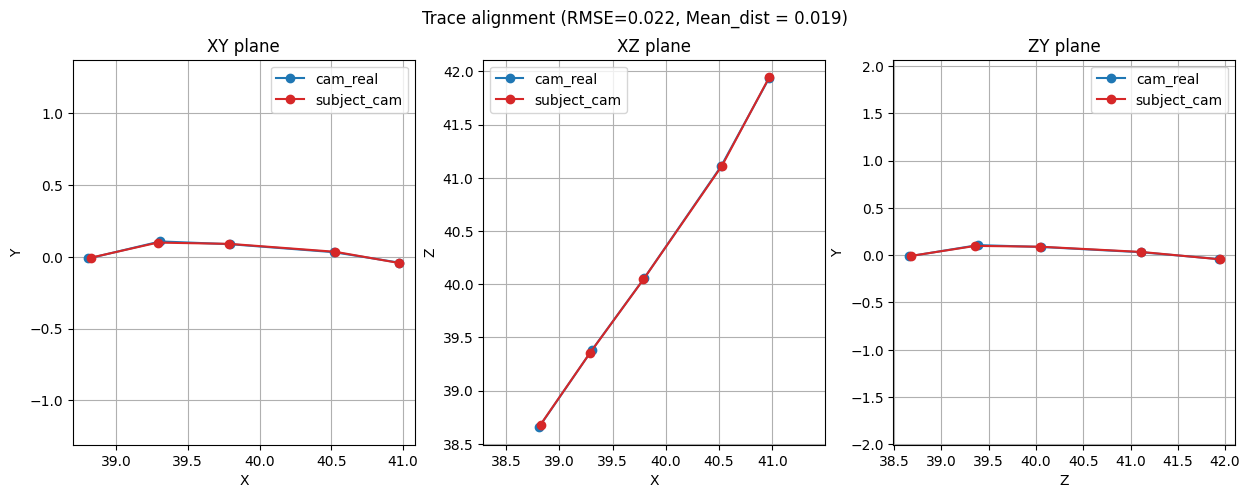

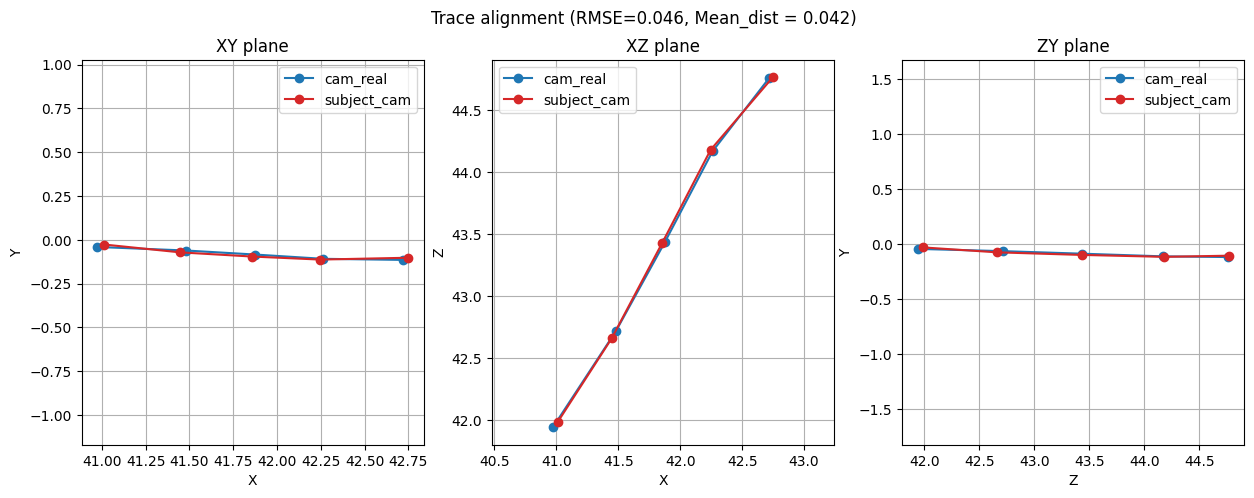

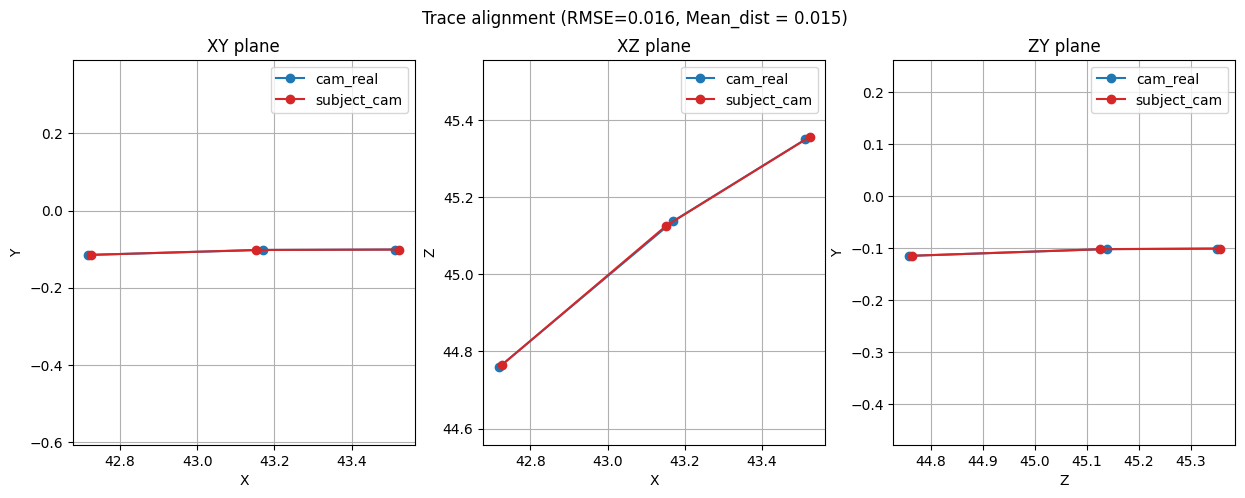

In [13]:
#SCALE CROSS-CHECK: three independent estimates of each junction's model_(i+1)->model_i scale
#1) intrinsics fx/fy ratio (already used in the merge cell above)
#2) depth-based least-squares fit on the shared frame's confident points (the original approach)
#3) GPS-only: register EACH shard independently against cam_poses_realworld_dict, then take the
#   RATIO of the two shards' own GPS-derived scales. Rotation from this per-shard GPS fit is NOT
#   trustworthy (Z-roll degeneracy on a near-straight path - why we don't use it for R,t) but SCALE
#   from position-magnitude matching doesn't share that degeneracy, so it's a genuinely independent
#   third number, using zero pixel depth and zero shared-frame intrinsics.
from F_alignments import recon_to_recon_transform

#independent GPS-only registration, per shard - only s_gps[i] is trustworthy from this, not R/t
s_gps = []
for i in range(len(recons)):
    _, s_gps_i, _ = recon_to_recon_transform(recons[i], cam_poses_realworld_dict)
    s_gps.append(s_gps_i)
    print(f"shard {i}: GPS-only scale (model_{i} -> world) = {s_gps_i:.4f}")

print()
for i in range(len(recons) - 1):
    #--- 1) intrinsics fx/fy ratio, same formula as the merge cell ---
    intr_to   = recons[i].preds["intrinsic"][-1].cpu().numpy()
    intr_from = recons[i+1].preds["intrinsic"][0].cpu().numpy()
    fx_ratio = intr_from[0, 0] / intr_to[0, 0]
    fy_ratio = intr_from[1, 1] / intr_to[1, 1]
    s_intrinsics = np.sqrt(fx_ratio * fy_ratio)

    #--- 2) depth-based least-squares fit on the shared frame's confident points ---
    extr = recons[i].preds["extrinsic"][-1].cpu().numpy()
    R_cm = extr[:3, :3].T
    t_cm = -R_cm @ extr[:3, 3]
    conf_to   = recons[i].preds["depth_conf"][-1].reshape(-1).cpu().numpy()
    conf_from = recons[i+1].preds["depth_conf"][0].reshape(-1).cpu().numpy()
    valid = (conf_to > 1.5) & (conf_from > 1.5)
    points_to   = recons[i].preds["model_points_from_depth"][-1].reshape(-1, 3).cpu().numpy()[valid]
    points_from = recons[i+1].preds["model_points_from_depth"][0].reshape(-1, 3).cpu().numpy()[valid]
    u = (R_cm @ points_from.T).T
    v = points_to - t_cm
    s_depth = np.sum(u * v) / np.sum(u * u)

    #--- 3) GPS-implied junction scale: ratio of the two shards' independent GPS-derived scales ---
    s_gps_junction = s_gps[i + 1] / s_gps[i]

    print(f"junction {i}->{i+1}:")
    print(f"  intrinsics ratio : {s_intrinsics:.4f}")
    print(f"  depth-based fit  : {s_depth:.4f}")
    print(f"  GPS-implied      : {s_gps_junction:.4f}")
    print()


In [19]:
#SUBJECT ANALYSIS
from subject_analysis import subject_to_metric_and_gps_space

sub_rw_dicts = {
    i: subject_to_metric_and_gps_space(
        recons[i],
        masks_dir=str(yolo_masks_dir),
        lat_0=lat_0, lon_0=lon_0,
        cam_poses_realworld_dict=cam_poses_realworld_dict,
        R_mw=merge_xforms[i][0], s_mw=merge_xforms[i][1], t_mw=merge_xforms[i][2],
    )
    for i in range(len(recons))
}
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)

Text(0.5, 1.0, 'Subject position by shard (color = time)')

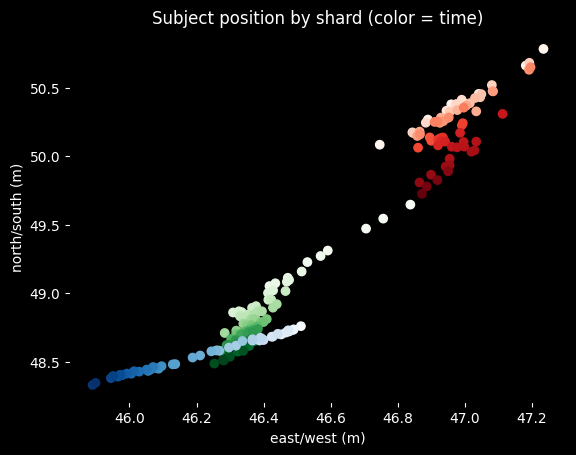

In [40]:
#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)
y_0 = sub_rw_dicts[0][1][:,2]
x_0 = sub_rw_dicts[0][1][:,0]
y_1 = sub_rw_dicts[1][1][:,2]
x_1 = sub_rw_dicts[1][1][:,0]
y_2 = sub_rw_dicts[2][1][:,2]
x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.scatter(x_0, y_0, c=np.arange(len(x_0)), cmap="Reds")
ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west (m)")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position by shard (color = time)")




shards 0 & 1: 1 overlapping frame(s)
  frame 3954: shard0=[46.87210769  0.9481133  49.72635378]  shard1=[46.83772071  0.86595839 49.64741826]  dist=0.119 m
shards 1 & 2: 1 overlapping frame(s)
  frame 4053: shard1=[46.28104043  0.91917503 48.50991709]  shard2=[46.51132168  1.07405268 48.76038191]  dist=0.374 m


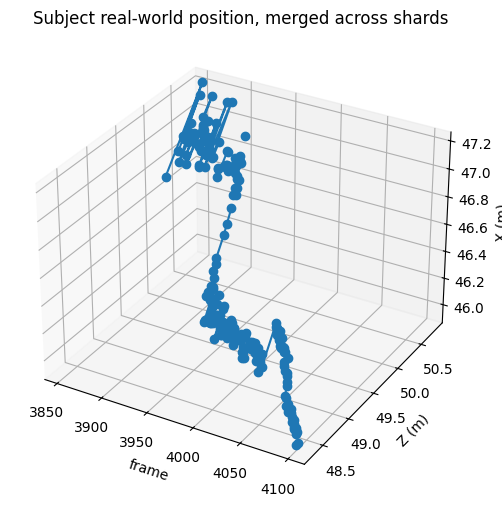

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - registers the 3d projection
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations


def merge_pos(*sub_pos_real_dicts):
    # check every pair of shards for frame numbers they both have a subject position for,
    # and how far apart their independent estimates land in real-world metres
    for (i, a), (j, b) in combinations(enumerate(sub_pos_real_dicts), 2):
        shared_keys = sorted(set(a) & set(b))
        if not shared_keys:
            continue
        print(f"shards {i} & {j}: {len(shared_keys)} overlapping frame(s)")
        for k in shared_keys:
            pa, pb = a[k], b[k]
            dist = np.linalg.norm(pa - pb)  # distance between points - the mismatch in modelling
            print(f"  frame {k}: shard{i}={pa}  shard{j}={pb}  dist={dist:.3f} m")

    # merge - later shard wins on collision (same behaviour as before, now with visibility into what's being dropped)
    sub_pos_real_dict_all = {}
    for d in sub_pos_real_dicts:
        sub_pos_real_dict_all.update(d)
    return sub_pos_real_dict_all


def graph_positions_3D(positions_dict):
    keys = np.array(sorted(positions_dict.keys()))
    pos  = np.array([positions_dict[k] for k in keys])   # (N, 3)
    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(keys, pos[:, 2], pos[:, 0], "o-")
    ax.set_xlabel("frame")
    ax.set_ylabel("Z (m)")
    ax.set_zlabel("X (m)")
    ax.set_title("Subject real-world position, merged across shards")
    plt.show()

#unpack resutls to get the postoins dicts
sub_pos_real_dicts = [v[2] for v in sub_rw_dicts.values()]
sub_pos_real_dict_all = merge_pos(*sub_pos_real_dicts)
graph_positions(sub_pos_real_dict_all)

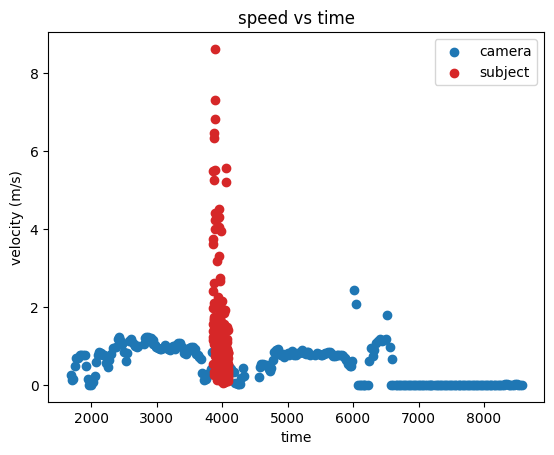

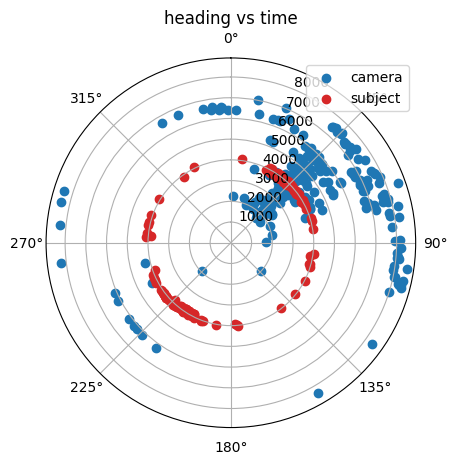

In [42]:
##Graphing and analysis of camera  TEMPORARY in here
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
fps = 30.07 #temp!
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict_0  , fps)
group_metrics = speed_direction((cam_poses_realworld_dict,sub_pos_real_dict_all),
                                 fps,                                 
                                 )



In [47]:
if PROJECTION_MAP == True:
    #2D projection mapping of subject to a selected view
    from E_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence

    

    subject_positions = projection_mapping_sequence(
        
        recon         = recons,
        main_idx      = 3900,
        extra_indices = range (3853,4100),
          #other syntax  [400,4027, 4052, 4065],
        masks_dir     = str(yolo_masks_dir),
        point_cloud_xforms = point_cloud_xforms
       
       )
else:
    print("Cell disabled")

attempting 3853
loading extra
didn't crash
attempting to write 3853
attempting 3854
loading extra
didn't crash
attempting to write 3854
attempting 3855
loading extra
didn't crash
attempting to write 3855
attempting 3856
loading extra
didn't crash
attempting to write 3856
attempting 3857
loading extra
didn't crash
attempting to write 3857
attempting 3858
loading extra
didn't crash
attempting to write 3858
attempting 3859
loading extra
didn't crash
attempting to write 3859
attempting 3860
loading extra
didn't crash
attempting to write 3860
attempting 3861
loading extra
didn't crash
attempting to write 3861
attempting 3862
loading extra
didn't crash
attempting to write 3862
attempting 3863
loading extra
didn't crash
attempting to write 3863
attempting 3864
loading extra
didn't crash
attempting to write 3864
attempting 3865
loading extra
didn't crash
attempting to write 3865
attempting 3866
loading extra
didn't crash
attempting to write 3866
attempting 3867
loading extra
didn't crash
attem

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
from U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if VGGT_O_RECON ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_04/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop